Opening dataset with dask chunks...
Extracting data at 71N, 306E...
Nearest grid point to (71, 54W) is (71.0, 306.0)
Maximum depth available: 5350.27197265625 m
Calculating depth-weighted average (300-500m)...
Computing result...
Done! Result shape: (453,)
Saving to data/reanalysis/EN4_temp_300-500m_71N_54W.nc...
Done!


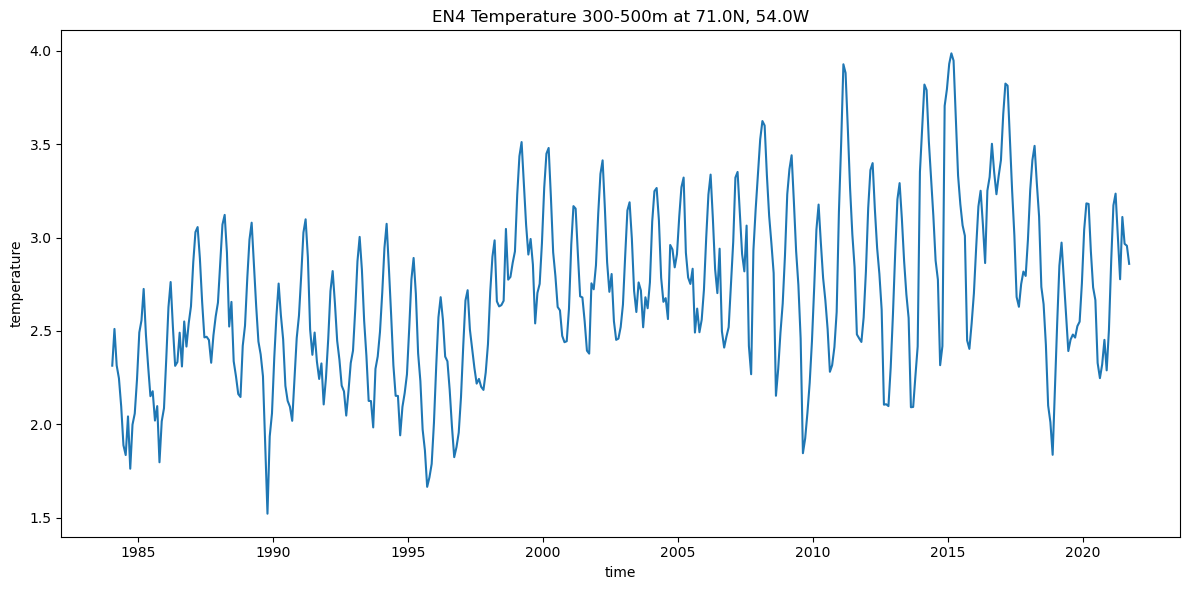

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

with open('config.yaml') as _f:
    cfg = yaml.safe_load(_f)

en4_dir = cfg['paths']['en4_dir']
data_dir = str(Path(en4_dir) / '*.nc')

print("Opening dataset with dask chunks...")
data = xr.open_mfdataset(data_dir, combine='by_coords', chunks='auto')

target_lat = 71
target_lon = -54
if target_lon < 0:
    target_lon = 360 + target_lon

print(f"Extracting data at {target_lat}N, {target_lon}E...")
temp_at_location = data['temperature'].sel(lat=target_lat, lon=target_lon, method='nearest')
nearest_lat = temp_at_location['lat'].values
nearest_lon = temp_at_location['lon'].values
print(f"Nearest grid point to ({target_lat}, {360-target_lon}W) is ({nearest_lat}, {nearest_lon})")

max_depth = temp_at_location['depth'].max().values
print(f"Maximum depth available: {max_depth} m")

print("Calculating depth-weighted average (300-500m)...")
depth_range = (300, 500)
temp_depth_filtered = temp_at_location.sel(depth=slice(depth_range[0], depth_range[1]))

depths = temp_depth_filtered['depth'].values
if len(depths) > 1:
    depth_mids = 0.5 * (depths[:-1] + depths[1:])
    layer_thickness = np.zeros(len(depths))
    layer_thickness[0] = depth_mids[0] - depth_range[0]
    layer_thickness[-1] = depth_range[1] - depth_mids[-1]
    layer_thickness[1:-1] = np.diff(depth_mids)
    weights = layer_thickness / layer_thickness.sum()
else:
    weights = np.array([1.0])

temp_weighted_avg = (temp_depth_filtered * weights).sum(dim='depth')
temp_weighted_avg = temp_weighted_avg - 273.15

print("Computing result...")
temp_weighted_avg = temp_weighted_avg.compute()
print(f"Done! Result shape: {temp_weighted_avg.shape}")

plt.figure(figsize=(12, 6))
temp_weighted_avg.plot()
plt.title(f'EN4 Temperature 300-500m at {nearest_lat}N, {360-nearest_lon}W')
plt.tight_layout()

temp_weighted_avg = temp_weighted_avg.assign_coords(lon=360 - temp_weighted_avg.lon)

out_path = 'data/reanalysis/EN4_temp_300-500m_71N_54W.nc'
print(f'Saving to {out_path}...')
temp_weighted_avg.to_netcdf(out_path)
print('Done!')